In [1]:
# Import necessary libraries
%load_ext autoreload
%autoreload 2

import sys
import os
import math

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', "..")))

# Import Mars library components
import mars
from mars import spin_model, spectra_manager, mesher, constants
from mars import utils
from mars import population

# # Let's import some useful functions for plotting simulation results over time.
from mars import visualization

In [2]:
dtype = torch.float64
device = torch.device("cpu")

### Define The samples

In [3]:
# Let's start from the sample creation
def get_samples(exchange_value: float):
    g_tensor_triplet = spin_model.Interaction([2.000, 2.002, 2.004], dtype=dtype, device=device)
    zfs_interaction = spin_model.DEInteraction([500e6, 100e6], dtype=dtype, device=device)  # 1000 and 100 MHz

    base_spin_system = spin_model.SpinSystem(
        electrons=[1.0],  # S=1 triplet
        g_tensors=[g_tensor_triplet],
        electron_electron=[(0, 0, zfs_interaction)]
    )

    triplet = spin_model.MultiOrientedSample(
        base_spin_system=base_spin_system,
        ham_strain=0.0,
        gauss=0.0015,
        lorentz=0.0015,
        device=device,
        mesh=(25, 25),
        dtype=dtype
    )

    g_tensor_doublet = spin_model.Interaction([2.02, 2.04, 2.25], dtype=dtype, device=device)
    base_spin_system = spin_model.SpinSystem(
        electrons=[0.5],  # S=0.5 triplet
        g_tensors=[g_tensor_doublet],
    )
    doublet = spin_model.MultiOrientedSample(
        base_spin_system=base_spin_system,
        ham_strain=0.0,
        gauss=0.002,
        lorentz=0.002,
        device=device,
        mesh=(25, 25),
        dtype=dtype
    )

    exchange_interaction = spin_model.Interaction(exchange_value, dtype=dtype, device=device)  # 500 and 100 MHz

    base_spin_system = spin_model.SpinSystem(
        electrons=[0.5, 1.0],  # S=0.5 triplet
        g_tensors=[g_tensor_doublet, g_tensor_triplet],
        electron_electron=[(1, 1, zfs_interaction), (0, 1, exchange_interaction)],
    )

    sample_complex = spin_model.MultiOrientedSample(
        base_spin_system=base_spin_system,
        ham_strain=0.0,
        gauss=0.002,
        lorentz=0.002,
        device=device,
        mesh=(25, 25),
        dtype=dtype
    )
    return doublet, triplet, sample_complex

In [4]:
temperature = 100.0
def get_contexts(temperature, doublet, triplet, sample_complex):
    # Find doublet population
    fields = torch.tensor([0.34], dtype=dtype)
    F, _, _, Gz = doublet.get_hamiltonian_terms()
    H = F + Gz * fields
    H  = H.unsqueeze(-3)
    energies, full_system_vectors = torch.linalg.eigh(H)

    populations_doublet = torch.softmax(
        constants.unit_converter(-energies, "Hz_to_K") / temperature, dim=-1
                                )[0, 0]

    enforce_secularity = False # It doesn't matter here

    context_triplet_xyz = population.Context(
        basis="xyz", sample=triplet, init_populations=[0.0, 0.0, 1.0], out_probs=[0.0, 0.0, 0.0], dtype=dtype, enforce_secularity=enforce_secularity)

    context_triplet_zeeman = population.Context(basis="zeeman", sample=triplet,
                                                free_probs=torch.tensor([[-0.0, 1e3, 0.0], 
                                                                         [1e3, -0.0, 1e3], 
                                                                         [0.0, 1e3, -0.0]],
                                                                        dtype=dtype),
                                                enforce_secularity=enforce_secularity, dtype=dtype,
                                               )

    context_doublet_pops = population.Context(basis="zeeman", sample=doublet, init_populations=populations_doublet,
                                                enforce_secularity=enforce_secularity, dtype=dtype
                                               )
    context_doublet_free = population.Context(basis="zeeman", sample=doublet, init_populations=populations_doublet,
                                                free_probs=torch.tensor([[-0.0, 1e4], 
                                                                         [1e4, -0.0]], dtype=dtype),
                                                 enforce_secularity=enforce_secularity, dtype=dtype)

    context_dephasing = population.Context(basis="eigen",
                                           sample=sample_complex, dephasing = [1e6 for _ in range(6)],
                                           enforce_secularity=enforce_secularity, dtype=dtype)
    context_doublet = context_doublet_free + context_doublet_free

    context_complex = mars.multiply((context_triplet_xyz + context_triplet_zeeman, context_doublet)) + context_dephasing
    return context_doublet, context_triplet_xyz + context_triplet_zeeman, context_complex

doublet, triplet, sample_complex = get_samples(100e6)
context_doublet, context_triplet, context_complex = get_contexts(temperature, doublet, triplet, sample_complex)

D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\population\contexts.py:2106: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(init_populations, dtype=dtype, device=device)
D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\population\contexts.py:2636: UserWarning: Note, after tensor-product multiplication the relaxation superoperator
may contain coherence–coherence transfer blocks. 
These blocks arise because different coherence pairscan share the same transition frequency,
and therefore they belong to the same Bohr-frequency sector.
As a result, extracting kinetic rates directlyfrom the transformed relaxation superoperatoris not always equivalent to using the kinetic rates extracted viacontext.get_transformed_free_probs or context.get_transformed_driven_probs

This effect becomes especially important when the initia

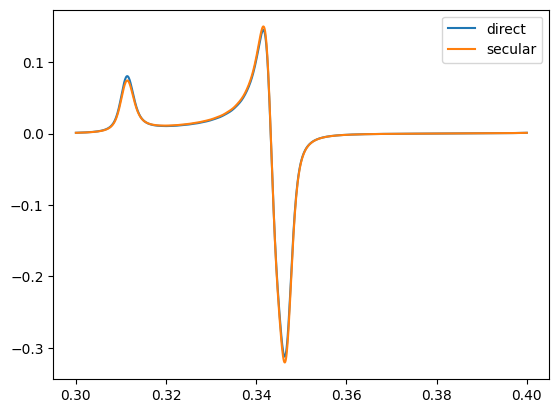

In [5]:
freq = 9.8 * 1e9
fields = torch.linspace(0.30, 0.40, 1000, dtype=dtype, device=device)

stationary = spectra_manager.StationarySpectra(
            freq=freq,
            sample=doublet,
            harmonic=1.0,
            context=context_doublet,
            temperature=temperature,
            device=device,
            dtype=dtype
        )
out = stationary(doublet, fields)

stationary_sec = spectra_manager.StationarySpectra(
            freq=freq,
            sample=doublet,
            harmonic=1.0,
            context=context_doublet,
            temperature=temperature,
            hamiltonian_mode="secular",
            device=device,
            dtype=dtype
        )
out_sec = stationary_sec(doublet, fields)


plt.plot(fields, out, label="direct")
plt.plot(fields, out_sec, label = "secular")
plt.legend()

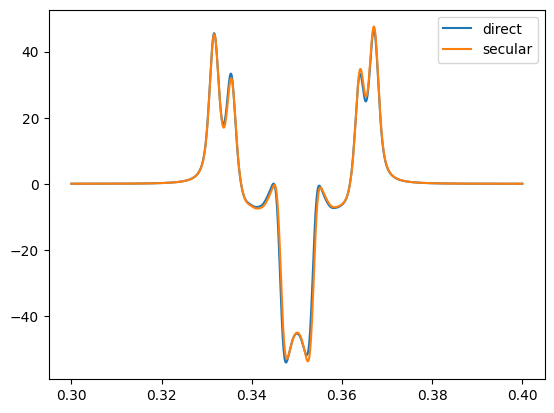

In [6]:
freq = 9.8 * 1e9
fields = torch.linspace(0.30, 0.40, 1000, dtype=dtype, device=device)

stationary = spectra_manager.StationarySpectra(
            freq=freq,
            sample=triplet,
            harmonic=1.0,
            context=context_triplet,
            temperature=temperature,
            device=device,
            dtype=dtype
        )
out = stationary(triplet, fields)


stationary_sec = spectra_manager.StationarySpectra(
            freq=freq,
            sample=triplet,
            harmonic=1.0,
            context=context_triplet,
            temperature=temperature,
            hamiltonian_mode="secular",
            device=device,
            dtype=dtype
        )
out_sec = stationary_sec(triplet, fields)


plt.plot(fields, out, label="direct")
plt.plot(fields, out_sec, label = "secular")
plt.legend()

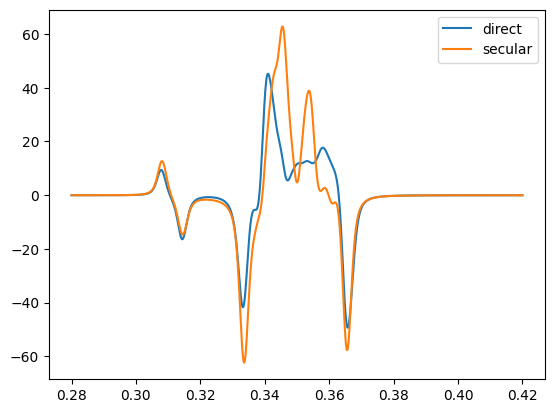

In [7]:
freq = 9.8 * 1e9
fields = torch.linspace(0.28, 0.42, 1000, dtype=dtype, device=device)

stationary = spectra_manager.StationarySpectra(
            freq=freq,
            sample=sample_complex,
            harmonic=1.0,
            context=context_complex,
            temperature=temperature,
            device=device,
            dtype=dtype
        )
out = stationary(sample_complex, fields)

stationary_sec = spectra_manager.StationarySpectra(
            freq=freq,
            sample=sample_complex,
            harmonic=1.0,
            context=context_complex,
            temperature=temperature,
            hamiltonian_mode="secular",
            device=device,
            dtype=dtype
        )


out_sec = stationary_sec(sample_complex, fields)
plt.plot(fields, out, label="direct")
plt.plot(fields, out_sec, label = "secular")
plt.legend()

In [8]:
def get_creators(doublet, triplet, sample_complex):

    freq = 9.8 * 1e9
    harmonic = 0
    fields = torch.linspace(0.28, 0.42, 1000, dtype=dtype, device=device)
    context_doublet, context_triplet, context_complex  = get_contexts(temperature, doublet, triplet, sample_complex)
    creators = [
        {
            "name": "Coupled",
            "instance": spectra_manager.CoupledTimeSpectra(
                freq=freq,
                sample=sample_complex,
                harmonic=harmonic,
                context=context_complex,
                temperature=temperature,
                hamiltonian_mode="direct",
                device=device,
                dtype=dtype
            )
        },
        {
            "name": "Density (RWA)",
            "instance": spectra_manager.DensityTimeSpectra(
                freq=freq,
                populator="rwa",
                sample=sample_complex,
                harmonic=harmonic,
                context=context_complex,
                temperature=temperature,
                device=device,
                dtype=dtype
            )
        },
        {
            "name": "Density (Propagator)",
            "instance": spectra_manager.DensityTimeSpectra(
                freq=freq,
                populator="propagator",
                sample=sample_complex,
                harmonic=harmonic,
                context=context_complex,
                temperature=temperature,
                hamiltonian_mode="direct",
                device=device,
                dtype=dtype
            )
        }
    ]
    return creators

In [9]:
def run_simulation(creators, doublet, triplet, sample_complex, tot_points, limit):
    time_long = torch.linspace(0.0, limit, tot_points, dtype=dtype, device=device)   # 100 us
    results = []

    print("Running simulations...")

    for c_idx, creator_data in enumerate(creators):
        creator = creator_data["instance"]
        name = creator_data["name"]

        print(f"Simulating {name}...")

        # Compute Short Time
        spec_long = creator(sample_complex, fields, time_long)

        results.append({
            "name": name,
            "long": {"time": time_long, "spectrum": spec_long}
        })

    # ==========================================
    # 3. NORMALIZATION
    # ==========================================

      # 10 ms

    print("Normalizing spectra...")
    target_norm_time = 200e-6
    for res in results:
        t_long = res["long"]["time"]
        spec_long = res["long"]["spectrum"]

        idx_norm = torch.argmin(torch.abs(t_long - target_norm_time)).item()
        max_val = torch.max(torch.abs(spec_long[idx_norm, :]))


        if max_val < 1e-12:
            max_val = 1.0
        res["long"]["spectrum"] = res["long"]["spectrum"] / max_val

        print(f"{res['name']}: Normalized by factor {max_val:.4e} at t=9us")
    return results

In [10]:
doublet, triplet, sample_complex = get_samples(50e6)
creators = get_creators(doublet, triplet, sample_complex)
result = run_simulation(creators, doublet, triplet, sample_complex, 100, 200e-6)

fig1, axes = plt.subplots(3, 1, figsize=(14, 10), sharex='col', sharey='row')

for i, res in enumerate(result):
    ax_short = axes[i]
    plt.sca(ax_short) 
    
    visualization.plot_2d_timeresolved(
        fields,
        res["long"]["time"],
        res["long"]["spectrum"],
        time_unit="us"
    )
    
    ax_short.set_title(f"{res['name']} (Short: 0-100 us)")
    plt.sca(ax_short)  # Set current axis for visualization function

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

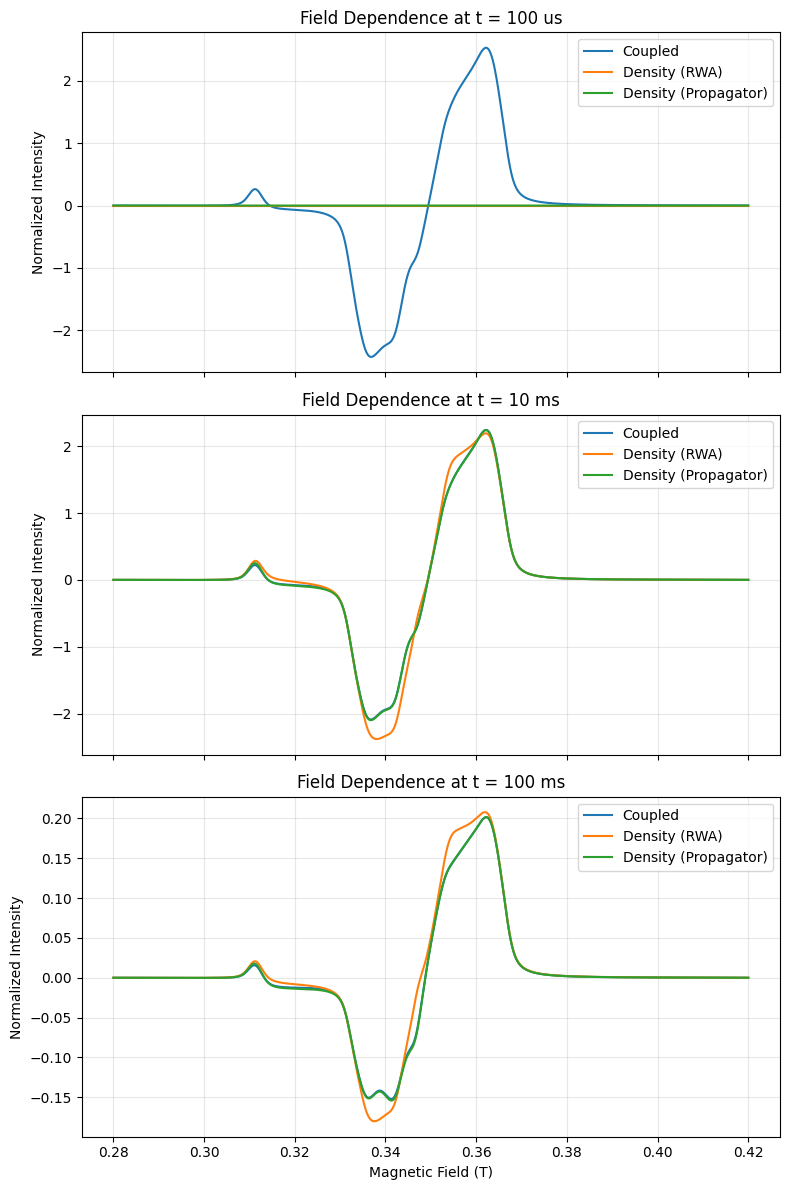

In [69]:
slice_times = [1e-6, 10e-6, 200e-6]
slice_labels = ["100 us", "10 ms", "100 ms"]

fig2, axes2 = plt.subplots(3, 1, figsize=(8, 12), sharex=True)
fields_cpu = fields.cpu().numpy()

for j, (t_target, t_label) in enumerate(zip(slice_times, slice_labels)):
    ax = axes2[j]
    ax.set_title(f"Field Dependence at t = {t_label}")
    ax.set_ylabel("Normalized Intensity")
    if j == 2:
        ax.set_xlabel("Magnetic Field (T)")
    
    for i, res in enumerate(result):
        t_arr = res["long"]["time"]
        spec_arr = res["long"]["spectrum"]
        source = "long"
        
        idx = torch.argmin(torch.abs(t_arr - t_target)).item()
        
        slice_data = spec_arr[idx, :].cpu().numpy()
        
        ax.plot(fields_cpu, slice_data, label=res["name"])
    
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Data Preparation for different J-values

In [12]:
J_values = [1e6, 50e6, 300e6]
### Short Results
doublet, triplet, sample_complex = get_samples(300e6)
creators = get_creators(doublet, triplet, sample_complex)
res_short = run_simulation(creators, doublet, triplet, sample_complex, 2800, 10e-6)

### Long Results

D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\population\contexts.py:2106: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(init_populations, dtype=dtype, device=device)
D:\ITC\РНФ_Курганский_2024\pythonProject\MarS\mars\population\contexts.py:2636: UserWarning: Note, after tensor-product multiplication the relaxation superoperator
may contain coherence–coherence transfer blocks. 
These blocks arise because different coherence pairscan share the same transition frequency,
and therefore they belong to the same Bohr-frequency sector.
As a result, extracting kinetic rates directlyfrom the transformed relaxation superoperatoris not always equivalent to using the kinetic rates extracted viacontext.get_transformed_free_probs or context.get_transformed_driven_probs

This effect becomes especially important when the initia

Running simulations...
Simulating Coupled...
Simulating Density (RWA)...
Simulating Density (Propagator)...
Normalizing spectra...
Coupled: Normalized by factor 8.2853e-02 at t=9us
Density (RWA): Normalized by factor 3.4500e+00 at t=9us
Density (Propagator): Normalized by factor 2.2939e+01 at t=9us


In [13]:
results = []
for J in J_values:
    doublet, triplet, sample_complex = get_samples(J)
    creators = get_creators(doublet, triplet, sample_complex)
    res = run_simulation(creators, doublet, triplet, sample_complex, 800, 200e-6)
    results.append(res)

Running simulations...
Simulating Coupled...
Simulating Density (RWA)...
Simulating Density (Propagator)...
Normalizing spectra...
Coupled: Normalized by factor 8.8023e-02 at t=9us
Density (RWA): Normalized by factor 2.5160e+00 at t=9us
Density (Propagator): Normalized by factor 2.4747e+01 at t=9us
Running simulations...
Simulating Coupled...
Simulating Density (RWA)...
Simulating Density (Propagator)...
Normalizing spectra...
Coupled: Normalized by factor 8.7108e-02 at t=9us
Density (RWA): Normalized by factor 2.6330e+00 at t=9us
Density (Propagator): Normalized by factor 2.3828e+01 at t=9us
Running simulations...
Simulating Coupled...
Simulating Density (RWA)...
Simulating Density (Propagator)...
Normalizing spectra...
Coupled: Normalized by factor 6.7017e-02 at t=9us
Density (RWA): Normalized by factor 3.0346e+00 at t=9us
Density (Propagator): Normalized by factor 1.8414e+01 at t=9us


In [ ]:
print("Normalizing spectra...")
target_norm_time = 200e-6
for result in results:
    for res in result:
        t_long = res["long"]["time"]
        spec_long = res["long"]["spectrum"]

        idx_norm = torch.argmin(torch.abs(t_long - target_norm_time)).item()
        max_val = torch.max(torch.abs(spec_long[idx_norm, :]))


        if max_val < 1e-12:
            max_val = 1.0
        res["long"]["spectrum"] = res["long"]["spectrum"] / max_val

        print(f"{res['name']}: Normalized by factor {max_val:.4e} at t=9us")

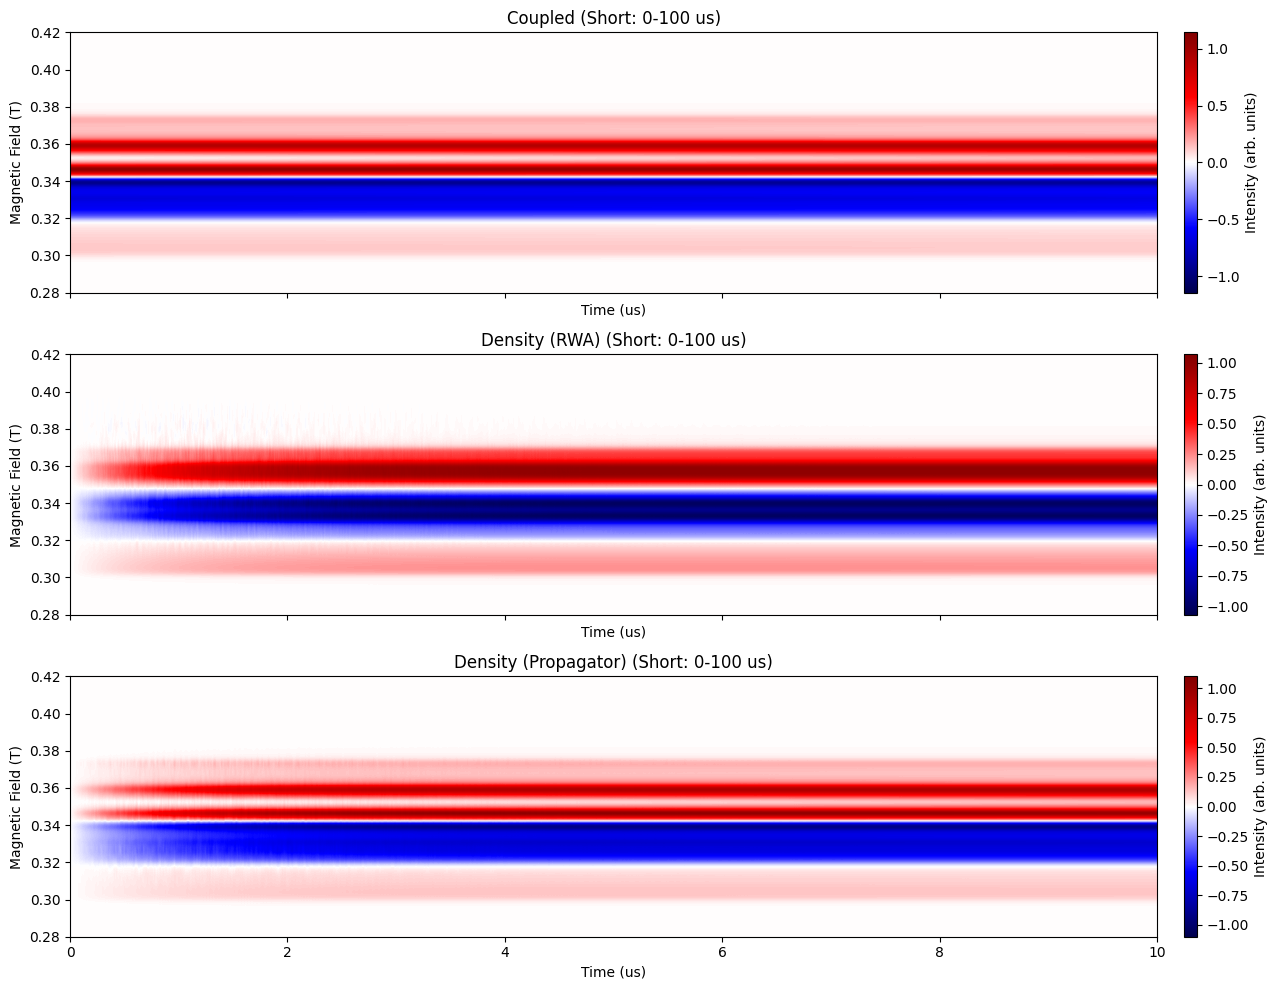

In [14]:
fig1, axes = plt.subplots(3, 1, figsize=(14, 10), sharex='col', sharey='row')

for i, res in enumerate(res_short):
    ax_short = axes[i]
    plt.sca(ax_short) 
    
    visualization.plot_2d_timeresolved(
        fields,
        res["long"]["time"],
        res["long"]["spectrum"],
        time_unit="us"
    )
    
    ax_short.set_title(f"{res['name']} (Short: 0-100 us)")
    plt.sca(ax_short)  # Set current axis for visualization function

plt.tight_layout()
plt.show()

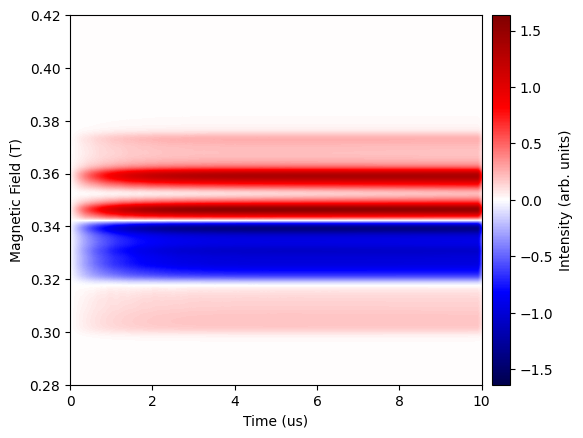

In [34]:
import torch.nn.functional as F

def smooth_tensor_pytorch(tensor, kernel_size=50):
    """
    Smooth tensor along axis 0 using a uniform moving average.
    Input: tensor of shape [N, M]
    """
    # Reshape to [1, M, N] for conv1d (channel, length)
    N, M = tensor.shape
    x = tensor.unsqueeze(0).transpose(1, 2)  # [1, M, N]

    
    kernel = torch.ones(M, 1, kernel_size, device=tensor.device, dtype=tensor.dtype) / kernel_size
    smoothed = F.conv1d(x, kernel, padding=kernel_size//2, groups=M)
    
    return smoothed.transpose(1, 2).squeeze(0)

spectrum = res_short[2]["long"]["spectrum"]
spectrum_smooth = smooth_tensor_pytorch(spectrum)

visualization.plot_2d_timeresolved(
    fields,
    res_short[2]["long"]["time"],
    spectrum_smooth * 1.5,
    time_unit="us"
)
plt.savefig("2d_time_resolved_spectrum_10us_propagator_300MHz_exchang.eps")

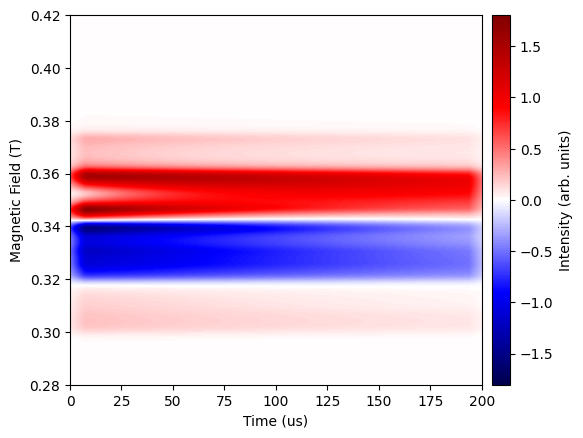

In [37]:
import torch.nn.functional as F

def smooth_tensor_pytorch(tensor, kernel_size=50):
    """
    Smooth tensor along axis 0 using a uniform moving average.
    Input: tensor of shape [N, M]
    """
    # Reshape to [1, M, N] for conv1d (channel, length)
    N, M = tensor.shape
    x = tensor.unsqueeze(0).transpose(1, 2)  # [1, M, N]

    
    kernel = torch.ones(M, 1, kernel_size, device=tensor.device, dtype=tensor.dtype) / kernel_size
    smoothed = F.conv1d(x, kernel, padding=kernel_size//2, groups=M)
    
    return smoothed.transpose(1, 2).squeeze(0)

spectrum = results[-1][2]["long"]["spectrum"]
spectrum_smooth = smooth_tensor_pytorch(spectrum)

visualization.plot_2d_timeresolved(
    fields,
    results[-1][2]["long"]["time"],
    spectrum_smooth,
    time_unit="us"
)
plt.savefig("2d_time_resolved_spectrum_200us_propagator_300MHz_exchang_long.eps")

In [ ]:
import torch.nn.functional as F

def smooth_tensor_pytorch(tensor, kernel_size=50):
    """
    Smooth tensor along axis 0 using a uniform moving average.
    Input: tensor of shape [N, M]
    """
    # Reshape to [1, M, N] for conv1d (channel, length)
    N, M = tensor.shape
    x = tensor.unsqueeze(0).transpose(1, 2)  # [1, M, N]

    
    kernel = torch.ones(M, 1, kernel_size, device=tensor.device, dtype=tensor.dtype) / kernel_size
    smoothed = F.conv1d(x, kernel, padding=kernel_size//2, groups=M)
    
    return smoothed.transpose(1, 2).squeeze(0)

spectrum = res_short[2]["long"]["spectrum"]
spectrum_smooth = smooth_tensor_pytorch(spectrum)

visualization.plot_2d_timeresolved(
    fields,
    res_short[2]["long"]["time"],
    spectrum_smooth * 1.5,
    time_unit="us"
)
plt.savefig("2d_time_resolved_spectrum_10us_propagator_300MHz_exchang.eps")

In [30]:
spectrum_smooth.max()

tensor(1.0391, dtype=torch.float64)

In [55]:
axes.shape

(2, 4)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


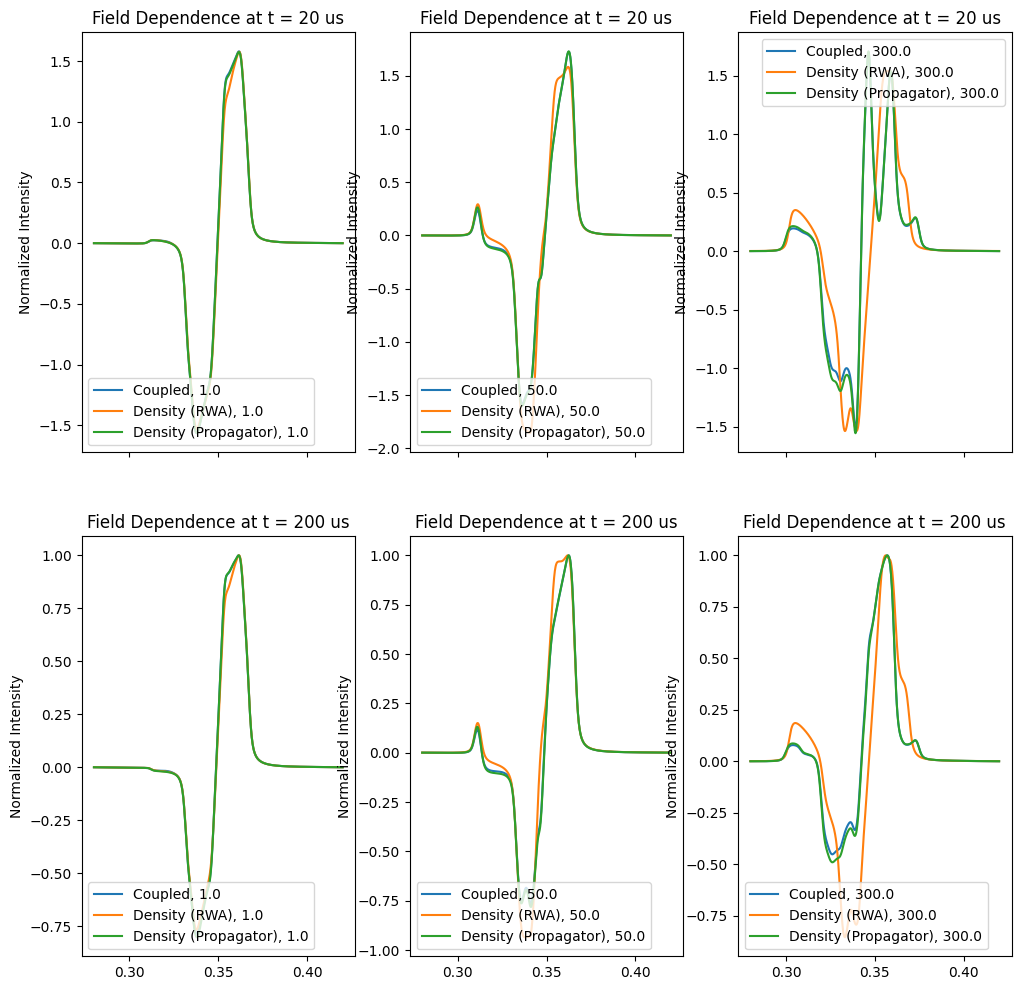

In [24]:
slice_times = [10e-6, 200e-6]
slice_labels = ["20 us", "200 us"]

fig2, axes = plt.subplots(2, 3, figsize=(12, 12), sharex=True)
fields_cpu = fields.cpu().numpy()

for i, result in enumerate(results):
    for j, (t_target, t_label) in enumerate(zip(slice_times, slice_labels)):
        ax = axes[j][i]
        ax.set_title(f"Field Dependence at t = {t_label}")
        ax.set_ylabel("Normalized Intensity")
        if j == 2:
            ax.set_xlabel("Magnetic Field (T)")

        for spec_num, res in enumerate(result):
            t_arr = res["long"]["time"]
            spec_arr = res["long"]["spectrum"]
            source = "long"

            idx = torch.argmin(torch.abs(t_arr - t_target)).item()

            slice_data = spec_arr[idx, :].cpu().numpy()
            ax.plot(fields_cpu, slice_data, label=f"{res['name']}, {J_values[i] / 1e6}")

        ax.legend(loc='best')
        
plt.savefig("2d_time_resolved_spectra_silces.eps")
plt.show()

# 3. Multiplication Correctness Check

In [8]:
fields = torch.tensor([0.3])
F, _, _, Gz = sample_complex.get_hamiltonian_terms()
H = F + Gz * fields
H  = H.unsqueeze(-3)
energies, full_system_vectors = torch.linalg.eigh(H)

# For the Redfield relaxation the driven probs return the rates, not free. It is supposed that thay shouldn't be modified futher
free = context_complex.get_transformed_free_probs(full_system_vectors, fields=fields.unsqueeze(-2), energies=energies, temperature=temperature)
out = context_complex.get_transformed_out_probs(full_system_vectors, fields=fields.unsqueeze(-2), energies=energies, temperature=temperature)
super_op = context_complex.get_transformed_free_superop(full_system_vectors, fields=fields.unsqueeze(-2), energies=energies, temperature=temperature)

DELITE HERE
DELITE HERE
DELITE HERE
DELITE HERE
DELITE HERE
DELITE HERE


In [9]:
super_op = population.transform.extract_transition_matrix_from_superoperator(super_op)[0, 0]
indexes = torch.arange(6)
super_op[..., indexes, indexes] = 0.0

In [10]:
super_op

tensor([[0.0000e+00, 1.9965e+04, 3.4558e+01, 9.8581e+02, 1.4157e+01, 2.7800e-06],
        [1.9965e+04, 0.0000e+00, 9.9546e+02, 3.4115e+01, 4.4325e-01, 2.2947e+00],
        [3.4558e+01, 9.9546e+02, 0.0000e+00, 1.9711e+04, 2.5481e+02, 9.9767e+02],
        [9.8581e+02, 3.4115e+01, 1.9711e+04, 0.0000e+00, 9.7212e+02, 2.5525e+02],
        [1.4157e+01, 4.4325e-01, 2.5481e+02, 9.7212e+02, 0.0000e+00, 1.9745e+04],
        [2.7800e-06, 2.2947e+00, 9.9767e+02, 2.5525e+02, 1.9745e+04, 0.0000e+00]],
       dtype=torch.float64)

In [11]:
free[0, 0]

tensor([[    0.0000, 19818.4892,  1276.6275, 20810.8872, 19567.8554,   217.1923],
        [19818.4892,     0.0000, 20842.0098,  1031.6552,   310.9770, 19939.8319],
        [ 1276.6275, 20842.0098,     0.0000, 19871.8060, 20590.6582,  1156.4243],
        [20810.8872,  1031.6552, 19871.8060,     0.0000,  1285.8115, 20908.9647],
        [19567.8554,   310.9770, 20590.6582,  1285.8115,     0.0000, 19686.4028],
        [  217.1923, 19939.8319,  1156.4243, 20908.9647, 19686.4028,     0.0000]],
       dtype=torch.float64)

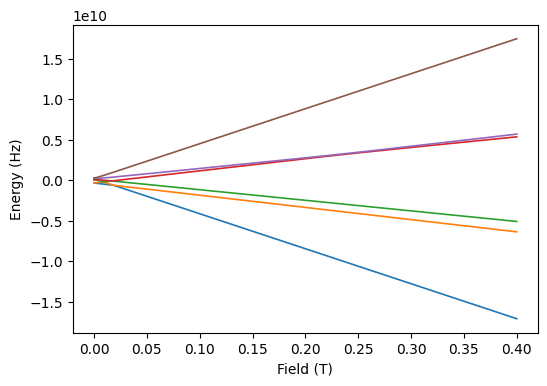

In [26]:
visualization.levels_plot.plot_energy_system(sample=sample_complex, B_range=(0.0, 0.4))

In [ ]:
### Case 1. We do not enforse secularity. In this case the Relaxation supeoperator after multiplication will have non-secular terms
### And after basis transformation it leads to the fact that kinetic computed from the supeoprators and dephasing computed
### from the supeoperator is different from the direct computation. That is

In [ ]:
diag_indices = torch.arange(6)

free_probs_triplet=torch.tensor([[-0.0, 1e3, 0.0], 
                         [1e3, -0.0, 1e3], 
                         [0.0, 1e3, -0.0]], dtype=dtype)
free_probs_doublet =torch.tensor([[-0.0, 1e4], 
                                  [1e4, -0.0]], dtype=dtype)
context_xyz = population.Context(basis="xyz", sample=triplet, free_probs=free_probs_triplet, enforce_secularity=False, dtype=dtype)
context_zeeman = population.Context(basis="zeeman", sample=doublet, free_probs=free_probs_doublet, enforce_secularity=False, dtype=dtype)       
context_complex = context_xyz @ context_zeeman


free = context_complex.get_transformed_free_probs(full_system_vectors, fields=fields.unsqueeze(-2), energies=energies, temperature=temperature)
super_op = context_complex.get_transformed_free_superop(full_system_vectors, fields=fields.unsqueeze(-2), energies=energies, temperature=temperature)
extracted = population.transform.extract_transition_matrix_from_superoperator(super_op)
extracted[..., diag_indices, diag_indices] =0.0
print(torch.allclose(extracted, free))  # False



free_probs_triplet=torch.tensor([[-0.0, 1e3, 0.0], 
                         [1e3, -0.0, 1e3], 
                         [0.0, 1e3, -0.0]], dtype=dtype)
free_probs_doublet =torch.tensor([[-0.0, 1e4], 
                                  [1e4, -0.0]], dtype=dtype)
context_xyz = population.Context(basis="xyz", sample=triplet, free_probs=free_probs_triplet, enforce_secularity=True, dtype=dtype)
context_zeeman = population.Context(basis="zeeman", sample=doublet, free_probs=free_probs_doublet, enforce_secularity=True, dtype=dtype)
context_complex = context_xyz @ context_zeeman

free = context_complex.get_transformed_free_probs(full_system_vectors, fields=fields.unsqueeze(-2), energies=energies, temperature=temperature)
super_op = context_complex.get_transformed_free_superop(full_system_vectors, fields=fields.unsqueeze(-2), energies=energies, temperature=temperature)
extracted = population.transform.extract_transition_matrix_from_superoperator(super_op)
extracted[..., diag_indices, diag_indices] =0.0
print(torch.allclose(extracted, free))  # True

In [17]:
import torch

def test_kinetic_vs_superoperator():
    """Compare transform_kronecker_rate_matrix_v2 with full superoperator + secular approx."""
    # System: two spin‑1/2 subsystems, active = second.
    dims = [2, 2]           # k1=2, k2=2
    total_dim = 4
    # Coefficients: product basis = eigenbasis (no mixing)
    coeffs = torch.eye(total_dim).reshape(2, 2, total_dim).to(torch.complex128)
    # Energies: for simplicity, all zero (so no energy filter needed)
    energies = torch.zeros(total_dim)
    # Rate matrix for active subsystem (second)
    W_sub = torch.tensor([[0., 1.], [2., 0.]], dtype=torch.float64)  # rate from 0→1 = 2, from 1→0 = 1
    matrices = [torch.eye(2, dtype=torch.float64), W_sub]

    # 1. Kinetic function output
    W_kinetic = population.transform.transform_kronecker_rate_matrix_v2(matrices, coeffs)  # shape (4,4)

    # 2. Build full superoperator in initial basis
    # Initial basis dimension = total_dim = 4
    # Vectorized density matrix size = 16
    L_super = torch.zeros((16, 16), dtype=torch.complex128)
    # Identity matrices
    I1 = torch.eye(2, dtype=torch.complex128)
    I2 = torch.eye(2, dtype=torch.complex128)
    # For active subsystem (s=1, second subsystem)
    ks = 2
    # Untouched subsystem (first) has dimension 2, so I_untouched = I1 (2x2)
    I_untouched = I1  # shape (2,2)
    for i in range(ks):
        for j in range(ks):
            rate = W_sub[i, j].item()
            if rate == 0:
                continue
            # L_ij = I_untouched ⊗ |i⟩⟨j|
            proj = torch.zeros((2,2), dtype=torch.complex128)
            proj[i,j] = 1.0
            L_ij = torch.kron(I_untouched, proj)  # shape (4,4)
            L_dag = L_ij.conj().T
            L_dag_L = L_dag @ L_ij
            # Kronecker products for vectorized superoperator
            term1 = torch.kron(L_ij, L_ij.conj())
            term2 = 0.5 * torch.kron(L_dag_L, torch.eye(4, dtype=torch.complex128))
            term3 = 0.5 * torch.kron(torch.eye(4, dtype=torch.complex128), L_dag_L.conj())
            L_super += rate * (term1 - term2 - term3)

    # 3. Transform to eigenbasis using U
    # U from coeffs: shape (total_dim, total_dim) with U[a,m] = ⟨a|m⟩
    # Here coeffs is identity: U = eye(4)
    U = coeffs.reshape(total_dim, total_dim).T  # shape (4,4)
    U_conj = U.conj()
    T = torch.kron(U, U_conj)      # shape (16,16)
    T_dag = T.conj().T
    L_super_eig = T_dag @ L_super @ T   # shape (16,16)

    # 4. Secular approximation: keep only population‑population block and zero if energies differ
    W_super = torch.zeros((total_dim, total_dim), dtype=torch.float64)
    for a in range(total_dim):
        for b in range(total_dim):
            if torch.isclose(energies[a], energies[b], rtol=1e-12, atol=1e-12):
                idx_aa = a * total_dim + a
                idx_bb = b * total_dim + b
                W_super[a, b] = L_super_eig[idx_aa, idx_bb].real
            else:
                W_super[a, b] = 0.0
    # Zero diagonal (losses are implicit)
    for a in range(total_dim):
        W_super[a, a] = 0.0

    # 5. Compare
    print("Kinetic function output:\n", W_kinetic)
    print("Superoperator + secular output:\n", W_super)
    assert torch.allclose(W_kinetic, W_super, atol=1e-6)
    print("Test passed: results match.")

# Run the test (assuming transform_kronecker_rate_matrix_v2 is defined)
test_kinetic_vs_superoperator()

Kinetic function output:
 tensor([[1., 1., 0., 0.],
        [2., 1., 0., 0.],
        [0., 0., 1., 1.],
        [0., 0., 2., 1.]], dtype=torch.float64)
Superoperator + secular output:
 tensor([[0., 1., 0., 0.],
        [2., 0., 0., 0.],
        [0., 0., 0., 1.],
        [0., 0., 2., 0.]], dtype=torch.float64)


AssertionError: 